# NBA MVP Vote Prediction 

## Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
DATA_PATH = Path("cleaned_data.csv")
TARGET_COL = "Pts Won"
SEASON_COL = "Year"
PLAYER_COL = "Player"

TEST_SEASONS_N = 2
VAL_SEASONS_N = 2
RANDOM_STATE = 42

USE_LOG_TARGET_FOR_STACK = False
STACK_N_SPLITS = 5
RIDGE_ALPHA_GRID = [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Put cleaned_data.csv in the same folder as this notebook "
        "or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Seasons: {df[SEASON_COL].min()} to {df[SEASON_COL].max()}")
print(f"Unique players: {df[PLAYER_COL].nunique() if PLAYER_COL in df.columns else 'N/A'}")
print(f"Rows with positive MVP points: {(df[TARGET_COL] > 0).sum()}")
display(df.head())

Shape: (17976, 45)
Seasons: 1980.0 to 2021.0
Unique players: 3275
Rows with positive MVP points: 697


,Unnamed: 0,Player,Ht,Wt,Colleges,Pos,Age,Tm,G,GS,...,Pts Max,Share,Team,W,L,W/L%,GB,PS/G,PA/G,SRS
0,0,Alaa Abdelnaby,6-10,240.0,Duke,PF,22,POR,43,0,...,0.0,0.0,Portland Trail Blazers,63,19,0.768,0.0,114.7,106.0,8.47
1,1,Danny Ainge,6-4,175.0,BYU,SG,31,POR,80,0,...,0.0,0.0,Portland Trail Blazers,63,19,0.768,0.0,114.7,106.0,8.47
2,2,Mark Bryant,6-9,245.0,Seton Hall,PF,25,POR,53,0,...,0.0,0.0,Portland Trail Blazers,63,19,0.768,0.0,114.7,106.0,8.47
3,3,Wayne Cooper,6-10,220.0,New Orleans,C,34,POR,67,1,...,0.0,0.0,Portland Trail Blazers,63,19,0.768,0.0,114.7,106.0,8.47
4,4,Walter Davis,6-6,193.0,UNC,SG,36,POR,71,14,...,0.0,0.0,Portland Trail Blazers,63,19,0.768,0.0,114.7,106.0,8.47


In [5]:
display(df.describe(include="all").T.head(20))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,17976.0,NaN,NaN,NaN,8987.5,5189.368555,0.0,4493.75,8987.5,13481.25,17975.0
Player,17976,3275,Charles Jones,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ht,17976,28,6-9,2093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wt,17976.0,NaN,NaN,NaN,215.879395,27.289579,133.0,195.0,215.0,235.0,360.0
Colleges,17976,650,Not American,1763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pos,17976,16,PF,3692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,17976.0,NaN,NaN,NaN,26.678961,4.089597,18.0,23.0,26.0,29.0,44.0
Tm,17976,40,PHI,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G,17976.0,NaN,NaN,NaN,54.055685,25.253982,1.0,35.0,62.0,77.0,85.0
GS,17976.0,NaN,NaN,NaN,27.303238,29.975434,0.0,1.0,12.0,55.0,84.0


In [6]:
def engineer_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()

    alias_map = {
        "PTS": "PPG",
        "TRB": "RPG",
        "AST": "APG",
        "STL": "SPG",
        "BLK": "BPG",
        "MP": "MPG",
        "TOV": "TPG",
    }
    for src, dst in alias_map.items():
        if src in df.columns and dst not in df.columns:
            df[dst] = df[src]

    if {"W", "L"}.issubset(df.columns):
        denom = (df["W"] + df["L"]).replace(0, np.nan)
        df["Win_Rate"] = (df["W"] / denom).fillna(0)

    if {"PTS", "FGA", "FTA"}.issubset(df.columns):
        denom = (2 * (df["FGA"] + 0.44 * df["FTA"])).replace(0, np.nan)
        df["TS%"] = (df["PTS"] / denom).fillna(0)

    if {"FGA", "FTA", "TOV", "MP"}.issubset(df.columns):
        denom = df["MP"].replace(0, np.nan)
        df["Usage"] = ((df["FGA"] + 0.44 * df["FTA"] + df["TOV"]) / denom).fillna(0)

    if {"G", "W", "L"}.issubset(df.columns):
        team_games = (df["W"] + df["L"]).replace(0, np.nan)
        df["Avail_Rate"] = (df["G"] / team_games).fillna(0)

    if {"PPG", "Win_Rate"}.issubset(df.columns):
        df["Scoring_Team_Impact"] = df["PPG"] * df["Win_Rate"]

    if {"TS%", "Avail_Rate"}.issubset(df.columns):
        df["Efficiency_Availability"] = df["TS%"] * df["Avail_Rate"]

    return df

df = engineer_features(df)
print("Engineered columns added. Current shape:", df.shape)

Engineered columns added. Current shape: (17976, 58)


## Season aware split

- oldest seasons as training
- next recent seasons as validation
- most recent seasons as test

In [7]:
all_seasons = sorted(df[SEASON_COL].dropna().unique())
assert len(all_seasons) >= (VAL_SEASONS_N + TEST_SEASONS_N + 1), "Not enough seasons for split."

test_seasons = all_seasons[-TEST_SEASONS_N:]
val_seasons = all_seasons[-(TEST_SEASONS_N + VAL_SEASONS_N):-TEST_SEASONS_N]
train_seasons = all_seasons[:-(TEST_SEASONS_N + VAL_SEASONS_N)]

train_df = df[df[SEASON_COL].isin(train_seasons)].copy()
val_df = df[df[SEASON_COL].isin(val_seasons)].copy()
test_df = df[df[SEASON_COL].isin(test_seasons)].copy()

print("Train seasons:", train_seasons)
print("Validation seasons:", val_seasons)
print("Test seasons:", test_seasons)
print()
print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")

Train seasons: [np.float64(1980.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), np.float64(1988.0), np.float64(1989.0), np.float64(1990.0), np.float64(1991.0), np.float64(1992.0), np.float64(1993.0), np.float64(1994.0), np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(1999.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0)]
Validation seasons: [np.float64(2018.0), np.float64(2019.0)]
Test seasons: [np.float64(2020.0), np.float64(2021.0)]

Train rows: 15835
Val rows:   1071
Test rows:  1070


In [8]:
candidate_features = [
    "W", "L", "Win_Rate", "PS/G", "PA/G",
    "PPG", "RPG", "APG", "SPG", "BPG", "MPG", "TPG",
    "FG%", "3P%", "2P%", "eFG%", "FT%", "TS%",
    "Usage", "G", "Age", "Avail_Rate",
    "Scoring_Team_Impact", "Efficiency_Availability",
]

feature_cols = [c for c in candidate_features if c in df.columns]
missing_feature_candidates = [c for c in candidate_features if c not in df.columns]

print("Selected features:")
print(feature_cols)
print("\nMissing feature candidates:")
print(missing_feature_candidates)

train_medians = train_df[feature_cols].median(numeric_only=True)

def prepare_xy(split_df: pd.DataFrame):
    X = split_df[feature_cols].copy()
    X = X.fillna(train_medians)
    y = split_df[TARGET_COL].copy()
    return X, y

X_train, y_train = prepare_xy(train_df)
X_val, y_val = prepare_xy(val_df)
X_test, y_test = prepare_xy(test_df)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)
trainval_df = pd.concat([train_df, val_df], axis=0)

print("Train features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)
print("Train+Val features:", X_trainval.shape)

Selected features:
['W', 'L', 'Win_Rate', 'PS/G', 'PA/G', 'PPG', 'RPG', 'APG', 'SPG', 'BPG', 'MPG', 'TPG', 'FG%', '3P%', '2P%', 'eFG%', 'FT%', 'TS%', 'Usage', 'G', 'Age', 'Avail_Rate', 'Scoring_Team_Impact', 'Efficiency_Availability']

Missing feature candidates:
[]
Train features: (15835, 24)
Validation features: (1071, 24)
Test features: (1070, 24)
Train+Val features: (16906, 24)


count    15835.000000
mean         6.589132
std         64.909756
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1310.000000
Name: Pts Won, dtype: float64


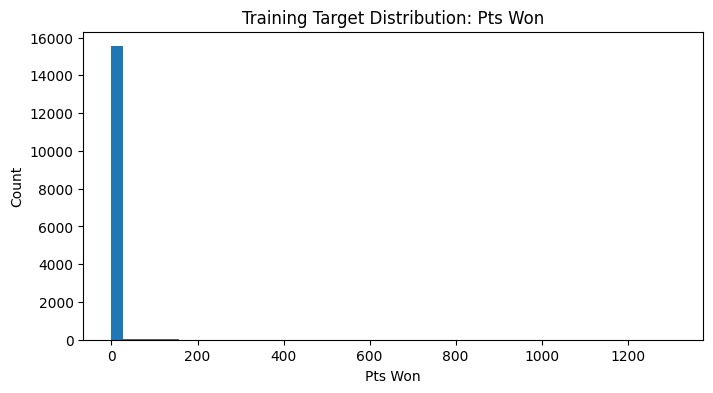

In [9]:
print(y_train.describe())

plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=50)
plt.title("Training Target Distribution: Pts Won")
plt.xlabel("Pts Won")
plt.ylabel("Count")
plt.show()

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def season_top1_accuracy(eval_df: pd.DataFrame, pred_col: str, actual_col: str = TARGET_COL, season_col: str = SEASON_COL):
    scores = []
    for season, grp in eval_df.groupby(season_col):
        actual_top = grp.sort_values(actual_col, ascending=False).iloc[0][PLAYER_COL] if PLAYER_COL in grp.columns else grp.sort_values(actual_col, ascending=False).index[0]
        pred_top = grp.sort_values(pred_col, ascending=False).iloc[0][PLAYER_COL] if PLAYER_COL in grp.columns else grp.sort_values(pred_col, ascending=False).index[0]
        scores.append(int(actual_top == pred_top))
    return float(np.mean(scores)) if scores else np.nan

def season_topk_overlap(eval_df: pd.DataFrame, pred_col: str, k: int = 5, actual_col: str = TARGET_COL, season_col: str = SEASON_COL):
    overlaps = []
    for season, grp in eval_df.groupby(season_col):
        if PLAYER_COL in grp.columns:
            actual_topk = set(grp.sort_values(actual_col, ascending=False).head(k)[PLAYER_COL])
            pred_topk = set(grp.sort_values(pred_col, ascending=False).head(k)[PLAYER_COL])
        else:
            actual_topk = set(grp.sort_values(actual_col, ascending=False).head(k).index)
            pred_topk = set(grp.sort_values(pred_col, ascending=False).head(k).index)

        overlaps.append(len(actual_topk.intersection(pred_topk)) / k)
    return float(np.mean(overlaps)) if overlaps else np.nan

def evaluate_predictions(model_name: str, y_true, y_pred, eval_df: pd.DataFrame):
    local_df = eval_df.copy()
    local_df["Predicted_Pts_Won"] = np.clip(y_pred, 0, None)

    return {
        "Model": model_name,
        "RMSE": rmse(y_true, local_df["Predicted_Pts_Won"]),
        "MAE": mean_absolute_error(y_true, local_df["Predicted_Pts_Won"]),
        "R²": r2_score(y_true, local_df["Predicted_Pts_Won"]),
        "Top1 Acc": season_top1_accuracy(local_df, "Predicted_Pts_Won"),
        "Top5 Overlap": season_topk_overlap(local_df, "Predicted_Pts_Won", k=5),
    }

## Baselines

In [11]:
baseline_models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
}

baseline_results = []
baseline_predictions = {}

for name, model in baseline_models.items():
    model.fit(X_trainval, y_trainval)
    pred_test = model.predict(X_test)
    baseline_predictions[name] = pred_test
    baseline_results.append(evaluate_predictions(name, y_test, pred_test, test_df))

baseline_results_df = pd.DataFrame(baseline_results).sort_values("RMSE")
display(baseline_results_df)

,Model,RMSE,MAE,R²,Top1 Acc,Top5 Overlap
2,Ridge,48.705371,15.481999,0.234052,0.5,0.7
1,Linear Regression,49.048371,16.306498,0.223226,0.5,0.7
0,Dummy Mean,55.673798,11.113900,-0.000800,0.0,0.0


## Strong standalone models

In [12]:
advanced_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=800,
        max_depth=16,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE,
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective="reg:squarederror",
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    ),
}

advanced_results = []
advanced_predictions = {}

for name, model in advanced_models.items():
    print(f"Training {name} ...")
    model.fit(X_trainval, y_trainval)
    pred_test = model.predict(X_test)
    advanced_predictions[name] = pred_test
    advanced_results.append(evaluate_predictions(name, y_test, pred_test, test_df))

advanced_results_df = pd.DataFrame(advanced_results).sort_values("RMSE")
display(advanced_results_df)

Training Random Forest ...
Training Gradient Boosting ...
Training XGBoost ...
Training LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4198
[LightGBM] [Info] Number of data points in the train set: 16906, number of used features: 24
[LightGBM] [Info] Start training from score 6.482367
Training CatBoost ...


,Model,RMSE,MAE,R²,Top1 Acc,Top5 Overlap
4,CatBoost,31.873950,4.487180,0.671967,0.5,0.7
3,LightGBM,32.256245,4.458004,0.664051,0.5,0.7
1,Gradient Boosting,32.887343,4.756298,0.650777,0.5,0.7
0,Random Forest,34.796803,5.502821,0.609047,0.5,0.8
2,XGBoost,36.136097,5.007829,0.578373,0.5,0.7


## proposed method: season aware stacked ensemble

In [13]:
stack_base_models = {
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    ),
}

passthrough_cols = [c for c in ["PPG", "APG", "RPG", "Win_Rate", "TS%", "G"] if c in X_trainval.columns]
print("Base models for stacking:", list(stack_base_models.keys()))
print("Passthrough columns:", passthrough_cols)

Base models for stacking: ['LightGBM', 'Gradient Boosting', 'CatBoost']
Passthrough columns: ['PPG', 'APG', 'RPG', 'Win_Rate', 'TS%', 'G']


In [14]:
def build_meta_features(
    X_train_meta_source,
    y_train_meta_source,
    X_test_target,
    group_labels,
    base_models,
    n_splits=5,
    use_log_target=False,
):
    gkf = GroupKFold(n_splits=n_splits)

    base_model_names = list(base_models.keys())
    oof_preds = np.zeros((len(X_train_meta_source), len(base_model_names)))
    test_preds = np.zeros((len(X_test_target), len(base_model_names)))

    y_model = np.log1p(y_train_meta_source) if use_log_target else y_train_meta_source.copy()

    oof_rmse_rows = []

    for model_idx, (model_name, model) in enumerate(base_models.items()):
        fold_test_preds = np.zeros((len(X_test_target), n_splits))
        fold_scores = []

        print(f"Generating OOF predictions for: {model_name}")

        for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train_meta_source, y_model, groups=group_labels)):
            X_tr = X_train_meta_source.iloc[tr_idx]
            X_va = X_train_meta_source.iloc[val_idx]
            y_tr = y_model.iloc[tr_idx]
            y_va = y_model.iloc[val_idx]

            fitted = clone(model)
            fitted.fit(X_tr, y_tr)

            pred_val = fitted.predict(X_va)
            pred_test = fitted.predict(X_test_target)

            oof_preds[val_idx, model_idx] = pred_val
            fold_test_preds[:, fold_idx] = pred_test

            if use_log_target:
                raw_pred_val = np.expm1(pred_val)
                raw_y_va = np.expm1(y_va)
            else:
                raw_pred_val = pred_val
                raw_y_va = y_va

            fold_rmse = rmse(raw_y_va, np.clip(raw_pred_val, 0, None))
            fold_scores.append(fold_rmse)

        test_preds[:, model_idx] = fold_test_preds.mean(axis=1)
        oof_rmse_rows.append({
            "Base Model": model_name,
            "OOF RMSE Mean": np.mean(fold_scores),
            "OOF RMSE Std": np.std(fold_scores),
        })

    oof_df = pd.DataFrame(oof_preds, columns=base_model_names, index=X_train_meta_source.index)
    test_df_meta = pd.DataFrame(test_preds, columns=base_model_names, index=X_test_target.index)
    oof_rmse_df = pd.DataFrame(oof_rmse_rows).sort_values("OOF RMSE Mean")

    return oof_df, test_df_meta, oof_rmse_df

In [15]:
trainval_groups = trainval_df[SEASON_COL].copy()

oof_meta_df, test_meta_df, oof_rmse_df = build_meta_features(
    X_train_meta_source=X_trainval,
    y_train_meta_source=y_trainval,
    X_test_target=X_test,
    group_labels=trainval_groups,
    base_models=stack_base_models,
    n_splits=min(STACK_N_SPLITS, trainval_groups.nunique()),
    use_log_target=USE_LOG_TARGET_FOR_STACK,
)

display(oof_rmse_df)
print("Meta-train shape before passthrough:", oof_meta_df.shape)
print("Meta-test shape before passthrough:", test_meta_df.shape)

Generating OOF predictions for: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4120
[LightGBM] [Info] Number of data points in the train set: 13521, number of used features: 24
[LightGBM] [Info] Start training from score 6.489453
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4181
[LightGBM] [Info] Number of data points in the train set: 13531, number of used features: 24
[LightGBM] [Info] Start training from score 6.493083
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4184
[LightGBM] [Inf

,Base Model,OOF RMSE Mean,OOF RMSE Std
2,CatBoost,35.624191,4.229657
0,LightGBM,36.806245,3.369420
1,Gradient Boosting,37.923490,4.613982


Meta-train shape before passthrough: (16906, 3)
Meta-test shape before passthrough: (1070, 3)


In [16]:
if passthrough_cols:
    X_meta_train = pd.concat(
        [oof_meta_df.reset_index(drop=True), X_trainval[passthrough_cols].reset_index(drop=True)],
        axis=1
    )
    X_meta_test = pd.concat(
        [test_meta_df.reset_index(drop=True), X_test[passthrough_cols].reset_index(drop=True)],
        axis=1
    )
else:
    X_meta_train = oof_meta_df.copy()
    X_meta_test = test_meta_df.copy()

print("Meta-train shape with passthrough:", X_meta_train.shape)
print("Meta-test shape with passthrough:", X_meta_test.shape)
display(X_meta_train.head())

Meta-train shape with passthrough: (16906, 9)
Meta-test shape with passthrough: (1070, 9)


,LightGBM,Gradient Boosting,CatBoost,PPG,APG,RPG,Win_Rate,TS%,G
0,-0.143317,-0.407246,-1.054654,3.1,0.3,2.1,0.768293,0.493631,43
1,0.567189,-0.407246,-1.409350,11.1,3.6,2.6,0.768293,0.575249,80
2,-0.143317,-0.407246,-0.840028,5.1,0.5,3.6,0.768293,0.550043,53
3,-0.143317,-0.407246,-0.464137,2.2,0.3,2.8,0.768293,0.446429,67
4,0.504417,-0.407246,-1.398640,13.0,1.8,2.5,0.768293,0.507654,71


In [17]:
alpha_search_rows = []
meta_target = np.log1p(y_trainval) if USE_LOG_TARGET_FOR_STACK else y_trainval.copy()
group_k = min(STACK_N_SPLITS, trainval_groups.nunique())
gkf_meta = GroupKFold(n_splits=group_k)

for alpha in RIDGE_ALPHA_GRID:
    fold_scores = []

    for tr_idx, va_idx in gkf_meta.split(X_meta_train, meta_target, groups=trainval_groups):
        X_tr = X_meta_train.iloc[tr_idx]
        X_va = X_meta_train.iloc[va_idx]
        y_tr = meta_target.iloc[tr_idx]
        y_va = meta_target.iloc[va_idx]

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr, y_tr)
        pred_va = ridge.predict(X_va)

        if USE_LOG_TARGET_FOR_STACK:
            raw_pred_va = np.expm1(pred_va)
            raw_y_va = np.expm1(y_va)
        else:
            raw_pred_va = pred_va
            raw_y_va = y_va

        fold_scores.append(rmse(raw_y_va, np.clip(raw_pred_va, 0, None)))

    alpha_search_rows.append({
        "alpha": alpha,
        "cv_rmse_mean": np.mean(fold_scores),
        "cv_rmse_std": np.std(fold_scores),
    })

alpha_search_df = pd.DataFrame(alpha_search_rows).sort_values("cv_rmse_mean").reset_index(drop=True)
display(alpha_search_df)

best_alpha = alpha_search_df.iloc[0]["alpha"]
print("Best Ridge alpha selected:", best_alpha)

,alpha,cv_rmse_mean,cv_rmse_std
0,100.00,35.758151,4.245456
1,50.00,35.758733,4.245549
2,25.00,35.759189,4.245651
3,10.00,35.759562,4.245747
4,5.00,35.759711,4.245787
5,1.00,35.759842,4.245824
6,0.10,35.759872,4.245833
7,0.01,35.759875,4.245833


Best Ridge alpha selected: 100.0


In [18]:
stack_meta_model = Ridge(alpha=best_alpha)
stack_meta_model.fit(X_meta_train, meta_target)
stack_pred_test = stack_meta_model.predict(X_meta_test)

if USE_LOG_TARGET_FOR_STACK:
    stack_pred_test = np.expm1(stack_pred_test)

stack_pred_test = np.clip(stack_pred_test, 0, None)

stack_results_df = pd.DataFrame([
    evaluate_predictions("Stacked Ensemble", y_test, stack_pred_test, test_df)
])
display(stack_results_df)

meta_coef_df = pd.DataFrame({
    "Meta Feature": X_meta_train.columns,
    "Weight": stack_meta_model.coef_
}).sort_values("Weight", key=lambda s: np.abs(s), ascending=False)

display(meta_coef_df)

,Model,RMSE,MAE,R²,Top1 Acc,Top5 Overlap
0,Stacked Ensemble,31.523249,4.479322,0.679146,0.5,0.7


,Meta Feature,Weight
2,CatBoost,0.771938
5,RPG,0.391913
4,APG,0.387307
0,LightGBM,0.277062
3,PPG,-0.256427
7,TS%,0.093642
1,Gradient Boosting,0.010344
8,G,0.003404
6,Win_Rate,0.001495


## results table

In [19]:
all_results_df = pd.concat(
    [baseline_results_df, advanced_results_df, stack_results_df],
    ignore_index=True
).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

display(all_results_df)

best_row = all_results_df.iloc[0]
print("Best overall model:")
display(best_row.to_frame().T)

,Model,RMSE,MAE,R²,Top1 Acc,Top5 Overlap
0,Stacked Ensemble,31.523249,4.479322,0.679146,0.5,0.7
1,CatBoost,31.873950,4.487180,0.671967,0.5,0.7
2,LightGBM,32.256245,4.458004,0.664051,0.5,0.7
3,Gradient Boosting,32.887343,4.756298,0.650777,0.5,0.7
4,Random Forest,34.796803,5.502821,0.609047,0.5,0.8
5,XGBoost,36.136097,5.007829,0.578373,0.5,0.7
6,Ridge,48.705371,15.481999,0.234052,0.5,0.7
7,Linear Regression,49.048371,16.306498,0.223226,0.5,0.7
8,Dummy Mean,55.673798,11.113900,-0.000800,0.0,0.0


Best overall model:


,Model,RMSE,MAE,R²,Top1 Acc,Top5 Overlap
0,Stacked Ensemble,31.523249,4.479322,0.679146,0.5,0.7


## Error analysis and season wise predictions

In [20]:
best_model_name = all_results_df.iloc[0]["Model"]

if best_model_name == "Stacked Ensemble":
    best_preds = stack_pred_test
elif best_model_name in baseline_predictions:
    best_preds = baseline_predictions[best_model_name]
else:
    best_preds = advanced_predictions[best_model_name]

analysis_df = test_df.copy()
analysis_df["Predicted_Pts_Won"] = np.clip(best_preds, 0, None)
analysis_df["Absolute_Error"] = np.abs(analysis_df[TARGET_COL] - analysis_df["Predicted_Pts_Won"])

display(
    analysis_df[[SEASON_COL, PLAYER_COL, TARGET_COL, "Predicted_Pts_Won", "Absolute_Error"]]
    .sort_values("Absolute_Error", ascending=False)
    .head(15)
)

,Year,Player,Pts Won,Predicted_Pts_Won,Absolute_Error
11076,2021.0,Nikola Jokić,971.0,482.771600,488.228400
17131,2021.0,Joel Embiid,586.0,188.161872,397.838128
5960,2020.0,James Harden,367.0,746.298845,379.298845
2817,2021.0,James Harden,1.0,312.921083,311.921083
12761,2021.0,Luka Dončić,42.0,344.955982,302.955982
6421,2020.0,Giannis Antetokounmpo,962.0,659.450143,302.549857
6459,2020.0,Anthony Davis,82.0,266.560412,184.560412
6464,2020.0,LeBron James,753.0,576.444322,176.555678
5969,2020.0,Russell Westbrook,0.0,175.407736,175.407736
2814,2021.0,Kevin Durant,0.0,162.154674,162.154674


In [21]:
for season, grp in analysis_df.groupby(SEASON_COL):
    print("=" * 80)
    print(f"Season: {season}")
    print("Actual Top 5:")
    display(grp.sort_values(TARGET_COL, ascending=False)[[PLAYER_COL, TARGET_COL]].head(5))
    print("Predicted Top 5:")
    display(grp.sort_values("Predicted_Pts_Won", ascending=False)[[PLAYER_COL, "Predicted_Pts_Won"]].head(5))

Season: 2020.0
Actual Top 5:


,Player,Pts Won
6421,Giannis Antetokounmpo,962.0
6464,LeBron James,753.0
5960,James Harden,367.0
10358,Luka Dončić,200.0
12730,Kawhi Leonard,168.0


Predicted Top 5:


,Player,Predicted_Pts_Won
5960,James Harden,746.298845
6421,Giannis Antetokounmpo,659.450143
6464,LeBron James,576.444322
6459,Anthony Davis,266.560412
10358,Luka Dončić,254.058594


Season: 2021.0
Actual Top 5:


,Player,Pts Won
11076,Nikola Jokić,971.0
17131,Joel Embiid,586.0
11632,Stephen Curry,453.0
1117,Giannis Antetokounmpo,348.0
3062,Chris Paul,139.0


Predicted Top 5:


,Player,Predicted_Pts_Won
11076,Nikola Jokić,482.771600
11632,Stephen Curry,389.299510
1117,Giannis Antetokounmpo,374.807710
12761,Luka Dončić,344.955982
2817,James Harden,312.921083
